## MNIST Klassifikator-Training (ResNet18) — Ziffernpaare 3-8, 4-9, 5-6
**Datensatz:** MNIST, auf drei binäre Teilprobleme reduziert (wie im Mirror-CFE Paper):
- `3 vs. 8`
- `4 vs. 9`
- `5 vs. 6`

**Modell:** Custom ResNet-18 (identische Bausteine wie in den Fire-/X-Ray-Notebooks),
Gate/Encoder auf 1×32×32-Eingaben angepasst (siehe Abschnitt 4).

Für jedes Paar wird ein eigener Klassifikator trainiert und als
`best_model_<pair>.pth` gespeichert (z.B. `best_model_38.pth`). Diese drei
Checkpoints sind die Grundlage für die nachfolgenden FCVE- und Mirror-CFE-Notebooks.


## 1. Setup & Konfiguration

In [1]:
# Imports
import os
import time
import random
import struct
from array import array
from os.path import join
from collections import OrderedDict, Counter
from functools import partial

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

torch.manual_seed(2024)
np.random.seed(2024)
random.seed(2024)


In [2]:
# Pfade (MNIST-Rohdaten, IDX-Format, wie auf Kaggle bereitgestellt -- kein Download noetig)
INPUT_PATH = '/kaggle/input/datasets/hojjatk/mnist-dataset'
TRAIN_IMAGES_PATH = join(INPUT_PATH, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
TRAIN_LABELS_PATH = join(INPUT_PATH, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
TEST_IMAGES_PATH  = join(INPUT_PATH, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
TEST_LABELS_PATH  = join(INPUT_PATH, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')
OUT_DIR     = './'                    # Checkpoints / Plots
PLOT_SUFFIX = 'training_plot'

# Bild / Normalisierung -- 0.5/0.5 (nicht der torchvision-MNIST-Standard!),
# konsistent mit dem Klassifikator-Checkpoint, den die FCVE-/Mirror-Notebooks erwarten.
IMAGE_SIZE  = 32                     # 28 -> 32 fuer saubere dyadische Downsampling-Stufen
MNIST_MEAN  = [0.5]
MNIST_STD   = [0.5]

# Training-Hyperparameter (identisch zur Fire-Struktur)
EPOCHS       = 15
BATCH_SIZE   = 128
LR           = 1e-3
WEIGHT_DECAY = 1e-4
VAL_SPLIT    = 0.1                   # 90/10 statt 80/20
NUM_WORKERS  = 2

# Die drei Ziffernpaare aus dem Mirror-CFE Paper.
# Konvention: Klasse 0 = erste Ziffer, Klasse 1 = zweite Ziffer im Tupel.
TASK_PAIRS = {
    '38': (3, 8),
    '49': (4, 9),
    '56': (5, 6),
}


In [3]:
# Device automatisch waehlen (MPS / CUDA / CPU)
def get_device():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using Apple MPS (Metal Performance Shaders)")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Using CUDA ({torch.cuda.get_device_name(0)})")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device

device = get_device()


Using CUDA (Tesla T4)


## 2. Dataset — Ziffernpaar-Filterung
Lädt MNIST train/test über torchvision und filtert je Paar auf genau die zwei
Ziffern. Label 0 = erste Ziffer des Tupels, Label 1 = zweite Ziffer.

In [4]:
class MnistDataloader(object):
    """IDX-Format-Loader fuer MNIST (liest die rohen Kaggle-Dateien direkt, kein Download noetig)."""
    def __init__(self, training_images_filepath, training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath

    def read_images_labels(self, images_filepath, labels_filepath):
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError(f'Magic number mismatch, expected 2049, got {magic}')
            labels = array("B", file.read())
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError(f'Magic number mismatch, expected 2051, got {magic}')
            image_data = array("B", file.read())
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img
        return images, labels

    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train), (x_test, y_test)


mnist_dataloader = MnistDataloader(TRAIN_IMAGES_PATH, TRAIN_LABELS_PATH,
                                    TEST_IMAGES_PATH, TEST_LABELS_PATH)
(x_train_all, y_train_all), (x_test_all, y_test_all) = mnist_dataloader.load_data()

x_train_all = np.array(x_train_all, dtype=np.uint8)
y_train_all = np.array(y_train_all, dtype=np.int64)
x_test_all  = np.array(x_test_all,  dtype=np.uint8)
y_test_all  = np.array(y_test_all,  dtype=np.int64)

print(f'MNIST geladen (IDX-Format) -- Train: {x_train_all.shape}  Test: {x_test_all.shape}')


def filter_and_remap(images, labels, d0, d1):
    """Behaelt nur Bilder von d0/d1, remapped Labels auf {0,1} (0=d0, 1=d1)."""
    mask = (labels == d0) | (labels == d1)
    imgs_f = images[mask]
    lbls_f = np.where(labels[mask] == d0, 0, 1).astype(np.int64)
    return imgs_f, lbls_f


class MNISTPairDataset(Dataset):
    """Nimmt bereits auf ein Ziffernpaar gefilterte (images, labels)-Arrays (uint8 28x28,
    Labels bereits 0/1) und wendet die torchvision-Transform-Pipeline an (Resize/Augment/
    Normalize). Ersetzt die vorherige torchvision.datasets.MNIST(download=True)-Variante,
    die auf Kaggle ohne Internetzugriff fehlschlaegt."""
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        label = int(self.labels[idx])
        if self.transform is not None:
            img = self.transform(img)
        return img, label

print('MnistDataloader + MNISTPairDataset definiert OK')


MNIST geladen (IDX-Format) -- Train: (60000, 28, 28)  Test: (10000, 28, 28)
MnistDataloader + MNISTPairDataset definiert OK


## 3. DataLoader

In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(degrees=8, translate=(0.05, 0.05)),  # leichte Augmentierung
    transforms.ToTensor(),
    transforms.Normalize(mean=MNIST_MEAN, std=MNIST_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MNIST_MEAN, std=MNIST_STD),
])


def get_dataloaders(digit_pair, batch_size=BATCH_SIZE, val_split=VAL_SPLIT,
                    num_workers=NUM_WORKERS):
    """
    Baut Train/Val-Loader fuer ein Ziffernpaar aus MNIST-train (IDX-Format).
    90/10-Split (Seed 42), Val-Set ohne Augmentierung. Der offizielle
    MNIST-Testsatz wird separat fuer Abschnitt 7 (Testen) verwendet.
    """
    d0, d1 = digit_pair
    imgs_f, lbls_f = filter_and_remap(x_train_all, y_train_all, d0, d1)

    n_val = int(len(imgs_f) * val_split)
    n_train = len(imgs_f) - n_val
    generator = torch.Generator().manual_seed(42)
    perm = torch.randperm(len(imgs_f), generator=generator).tolist()
    train_idx, val_idx = perm[:n_train], perm[n_train:]

    train_set = MNISTPairDataset(imgs_f[train_idx], lbls_f[train_idx], transform=train_transforms)
    val_set   = MNISTPairDataset(imgs_f[val_idx],   lbls_f[val_idx],   transform=val_transforms)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_set, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

    class_names = [str(d0), str(d1)]
    print(f'Paar {digit_pair}: Train={n_train}  Val={n_val}  Klassen={class_names}')
    return train_loader, val_loader, class_names


def get_test_loader(digit_pair, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
    d0, d1 = digit_pair
    imgs_f, lbls_f = filter_and_remap(x_test_all, y_test_all, d0, d1)
    test_set = MNISTPairDataset(imgs_f, lbls_f, transform=val_transforms)
    return DataLoader(test_set, batch_size=batch_size, shuffle=False,
                      num_workers=num_workers, pin_memory=True)


Paar (3, 8): Train=10784  Val=1198  Klassen=['3', '8']


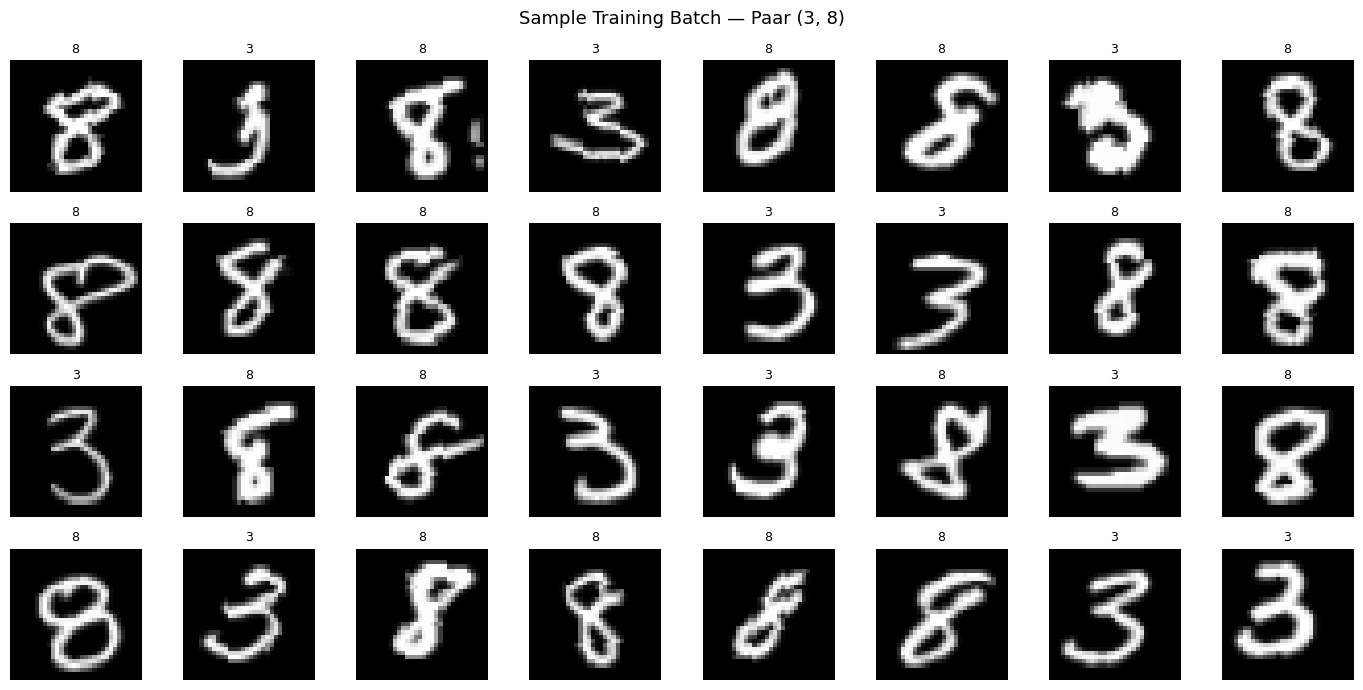

In [6]:
# Batch visualisieren (Beispiel: erstes Paar)
def denormalise(tensor):
    """Macht die MNIST-Normalisierung rueckgaengig fuer die Anzeige."""
    mean = torch.tensor(MNIST_MEAN).view(1, 1, 1)
    std  = torch.tensor(MNIST_STD).view(1, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

_demo_pair = TASK_PAIRS['38']
_demo_train, _demo_val, _demo_classes = get_dataloaders(_demo_pair)
images, labels = next(iter(_demo_train))

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for ax, img, lbl in zip(axes.flatten(), images[:32], labels[:32]):
    img_np = denormalise(img).squeeze(0).numpy()
    ax.imshow(img_np, cmap='gray')
    ax.set_title(_demo_classes[int(lbl.item())], fontsize=9)
    ax.axis('off')
plt.suptitle(f'Sample Training Batch — Paar {_demo_pair}', fontsize=13)
plt.tight_layout()
plt.show()


## 4. Modell — ResNet18 (identische Custom-Architektur wie Fire/X-Ray)

Gleiche Bausteine UND gleicher Gate (Stem) wie in den Fire-/X-Ray-Notebooks --
KEINE MNIST-spezifische Anpassung des Stems (7x7-Conv Stride 2 + MaxPool Stride 2 = /4
vor dem ersten Residual-Block, exakt wie im Original). Bei 32x32-Eingaben ergibt das eine
kleinere, aber zu Fire proportional identische Pyramide (jede Ebene im selben Verhaeltnis
zur Eingabegroesse):

`32x32 (Input) --Gate(/4)--> 8x8 (f1) --/2--> 4x4 (f2) --/2--> 2x2 (f3) --/2--> 1x1 (f4, GAP -> 512)`

(Fire zum Vergleich: `224 --/4--> 56 (f1) --/2--> 28 (f2) --/2--> 14 (f3) --/2--> 7 (f4)`,
selbes Verhaeltnis 1/4 : 1/8 : 1/16 : 1/32.) Diese Pyramide wird 1:1 von den FCVE-/Mirror-Decodern
in den Folgenotebooks wiederverwendet -- mit denselben Kanalzahlen und derselben Anzahl an
Upsampling-Stufen wie im Fire-Decoder.

In [7]:
class Conv2dAuto(nn.Conv2d):
    """Conv2d mit automatischem 'same' Padding basierend auf der Kernel-Groesse."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.padding = (self.kernel_size[0] // 2, self.kernel_size[1] // 2)


conv3x3 = partial(Conv2dAuto, kernel_size=3, bias=False)


class ResidualBlock(nn.Module):
    """Basis Residual Block: output = blocks(x) + shortcut(x)."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.blocks = nn.Identity()
        self.shortcut = nn.Identity()

    def forward(self, x):
        residual = self.shortcut(x) if self.should_apply_shortcut else x
        x = self.blocks(x)
        x += residual
        return x

    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.out_channels


class ResNetResidualBlock(ResidualBlock):
    """ResNet Residual Block mit Expansion und optionalem Downsampling."""
    def __init__(self, in_channels, out_channels, expansion=1,
                 downsampling=1, conv=conv3x3, *args, **kwargs):
        super().__init__(in_channels, out_channels)
        self.expansion = expansion
        self.downsampling = downsampling
        self.conv = conv
        self.shortcut = (
            nn.Sequential(OrderedDict({
                'conv': nn.Conv2d(self.in_channels, self.expanded_channels,
                                  kernel_size=1, stride=self.downsampling, bias=False),
                'bn': nn.BatchNorm2d(self.expanded_channels)
            }))
            if self.should_apply_shortcut else None
        )

    @property
    def expanded_channels(self):
        return self.out_channels * self.expansion

    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.expanded_channels


def conv_bn(in_channels, out_channels, conv, *args, **kwargs):
    """Convolution gefolgt von BatchNorm."""
    return nn.Sequential(OrderedDict({
        'conv': conv(in_channels, out_channels, *args, **kwargs),
        'bn': nn.BatchNorm2d(out_channels)
    }))


class ResNetBasicBlock(ResNetResidualBlock):
    """Basic Block: zwei 3x3 conv/bn Layer mit ReLU."""
    expansion = 1

    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels, self.out_channels, conv=self.conv,
                    bias=False, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels, conv=self.conv, bias=False),
        )


class ResNetLayer(nn.Module):
    """Ein Layer, bestehend aus n gestapelten Residual Blocks."""
    def __init__(self, in_channels, out_channels, block=ResNetBasicBlock, n=1, *args, **kwargs):
        super().__init__()
        downsampling = 2 if in_channels != out_channels else 1
        self.blocks = nn.Sequential(
            block(in_channels, out_channels, *args, **kwargs, downsampling=downsampling),
            *[block(out_channels * block.expansion, out_channels,
                    downsampling=1, *args, **kwargs) for _ in range(n - 1)]
        )

    def forward(self, x):
        return self.blocks(x)


class ResNetEncoder(nn.Module):
    """
    ResNet Encoder: Gate (Stem) gefolgt von Residual Layers.

    Gate-Defaults sind identisch zum Original-ResNet18 (Fire/X-Ray): kernel=7, stride=2,
    padding=3, pool=True (Downsampling /4). Fuer MNIST wird NICHTS davon veraendert --
    die kleinere Eingabegroesse (32x32 statt 224x224) ergibt einfach eine proportional
    kleinere Feature-Map-Pyramide (siehe Abschnitt 4).
    """
    def __init__(self, in_channels=3, blocks_sizes=(64, 128, 256, 512),
                 depths=(2, 2, 2, 2), activation=nn.ReLU,
                 block=ResNetBasicBlock,
                 gate_kernel=7, gate_stride=2, gate_padding=3, gate_pool=True,
                 *args, **kwargs):
        super().__init__()
        self.blocks_sizes = blocks_sizes

        gate_layers = [
            nn.Conv2d(in_channels, blocks_sizes[0], kernel_size=gate_kernel,
                      stride=gate_stride, padding=gate_padding, bias=False),
            nn.BatchNorm2d(blocks_sizes[0]),
            activation(),
        ]
        if gate_pool:
            gate_layers.append(nn.MaxPool2d(kernel_size=3, stride=2, padding=1))
        self.gate = nn.Sequential(*gate_layers)

        self.in_out_block_sizes = list(zip(blocks_sizes, blocks_sizes[1:]))
        self.blocks = nn.ModuleList([
            ResNetLayer(blocks_sizes[0], blocks_sizes[0], n=depths[0],
                        activation=activation, block=block, *args, **kwargs),
            *[ResNetLayer(in_ch * block.expansion, out_ch, n=n,
                          activation=activation, block=block, *args, **kwargs)
              for (in_ch, out_ch), n in zip(self.in_out_block_sizes, depths[1:])]
        ])

    def forward(self, x):
        x = self.gate(x)
        for block in self.blocks:
            x = block(x)
        return x


class ResNetDecoder(nn.Module):
    """Global Average Pool gefolgt von Fully Connected Classifier."""
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d((1, 1))
        self.decoder = nn.Linear(in_features, n_classes)

    def forward(self, x):
        x = self.avg(x)
        x = x.view(x.size(0), -1)
        x = self.decoder(x)
        return x


class ResNet(nn.Module):
    """Komplettes ResNet: Encoder + Decoder."""
    def __init__(self, in_channels, n_classes, *args, **kwargs):
        super().__init__()
        self.encoder = ResNetEncoder(in_channels, *args, **kwargs)
        self.decoder = ResNetDecoder(
            self.encoder.blocks[-1].blocks[-1].expanded_channels, n_classes
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


# Factory Function -- MNIST-Variante: gleiche Architektur wie Fire (resnet18()),
# nur in_channels=1 (Graustufen) und n_classes=2 (binaeres Ziffernpaar). Der Gate
# bleibt UNVERAENDERT (kernel=7, stride=2, padding=3, pool=True -- Encoder-Defaults).
def resnet18_mnist(in_channels=1, n_classes=2):
    return ResNet(in_channels, n_classes, block=ResNetBasicBlock, depths=[2, 2, 2, 2])


# Sanity Check: Feature-Map-Groessen pruefen
with torch.no_grad():
    _dummy = torch.zeros(2, 1, IMAGE_SIZE, IMAGE_SIZE)
    _m = resnet18_mnist()
    _out = _m(_dummy)
    print('Output-Shape:', _out.shape, '(erwartet: [2, 2])')
    print(f'Parameter: {sum(p.numel() for p in _m.parameters()):,}')

    _fmaps = {}
    _hooks = []
    for _n, _l in zip(['f1','f2','f3','f4'], _m.encoder.blocks):
        _hooks.append(_l.register_forward_hook(lambda m,i,o,n=_n: _fmaps.update({n:o})))
    _ = _m(_dummy)
    for _h in _hooks: _h.remove()
    for _n in ['f1','f2','f3','f4']:
        print(f'  {_n}: {_fmaps[_n].shape}')
del _dummy, _m, _out, _fmaps, _hooks


Output-Shape: torch.Size([2, 2]) (erwartet: [2, 2])
Parameter: 11,171,266
  f1: torch.Size([2, 64, 8, 8])
  f2: torch.Size([2, 128, 4, 4])
  f3: torch.Size([2, 256, 2, 2])
  f4: torch.Size([2, 512, 1, 1])


## 5. Training

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


In [9]:
def train_task(pair_key, digit_pair, epochs=EPOCHS):
    """Trainiert einen binaeren Klassifikator fuer ein Ziffernpaar und
    speichert den besten Checkpoint (nach Val-Accuracy) als
    best_model_<pair_key>.pth -- analog zum Fire-Notebook."""
    print(f'\n{"="*70}')
    print(f'Training Paar {pair_key}: {digit_pair}')
    print(f'{"="*70}')

    train_loader, val_loader, class_names = get_dataloaders(digit_pair)

    model = resnet18_mnist(in_channels=1, n_classes=2).to(device)
    print(f'Model: ResNet18 (MNIST)  |  Parameters: {sum(p.numel() for p in model.parameters()):,}')

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    model_save_path = os.path.join(OUT_DIR, f'best_model_{pair_key}.pth')

    print(f"\n{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>10}  {'Val Acc':>9}  {'Time':>6}")
    print('-' * 62)

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step()
        elapsed = time.time() - t0

        marker = '*' if val_acc > best_val_acc else ''
        print(f'{epoch:5d}  {train_loss:10.4f}  {train_acc:8.2%}  {val_loss:10.4f}  {val_acc:8.2%}  {elapsed:5.1f}s {marker}')

        train_losses.append(train_loss); val_losses.append(val_loss)
        train_accs.append(train_acc);   val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'class_names': class_names,
                'digit_pair': digit_pair,
                'image_size': IMAGE_SIZE,
            }, model_save_path)

    print(f'\nTraining Paar {pair_key} abgeschlossen. Beste Val-Accuracy: {best_val_acc:.2%}')
    print(f'Model gespeichert: {os.path.abspath(model_save_path)}')

    return {
        'pair_key': pair_key, 'digit_pair': digit_pair, 'class_names': class_names,
        'train_losses': train_losses, 'val_losses': val_losses,
        'train_accs': train_accs, 'val_accs': val_accs, 'best_val_acc': best_val_acc,
    }


In [10]:
# Alle drei Paare trainieren
results = {}
for pair_key, digit_pair in TASK_PAIRS.items():
    results[pair_key] = train_task(pair_key, digit_pair, epochs=EPOCHS)

print('\n' + '=' * 70)
print('Zusammenfassung')
print('=' * 70)
for pair_key, res in results.items():
    print(f"  {pair_key} {res['digit_pair']}: Beste Val-Accuracy = {res['best_val_acc']:.2%}")



Training Paar 38: (3, 8)
Paar (3, 8): Train=10784  Val=1198  Klassen=['3', '8']
Model: ResNet18 (MNIST)  |  Parameters: 11,171,266

Epoch  Train Loss  Train Acc    Val Loss    Val Acc    Time
--------------------------------------------------------------
    1      0.1616    96.53%      0.0162    99.25%    6.7s *
    2      0.0221    99.23%      0.1407    94.32%    4.3s 
    3      0.0124    99.56%      0.0171    99.50%    4.3s *
    4      0.0117    99.63%      0.0066    99.92%    4.4s *
    5      0.0131    99.56%      0.0035    99.83%    4.5s 
    6      0.0090    99.71%      0.0019   100.00%    4.5s *
    7      0.0083    99.73%      0.0309    98.66%    4.5s 
    8      0.0057    99.79%      0.0020   100.00%    4.6s 
    9      0.0073    99.76%      0.0015    99.92%    4.7s 
   10      0.0034    99.86%      0.0012    99.92%    4.7s 
   11      0.0043    99.88%      0.0005   100.00%    4.8s 
   12      0.0032    99.91%      0.0003   100.00%    4.8s 
   13      0.0025    99.87%     

## 6. Trainingskurven

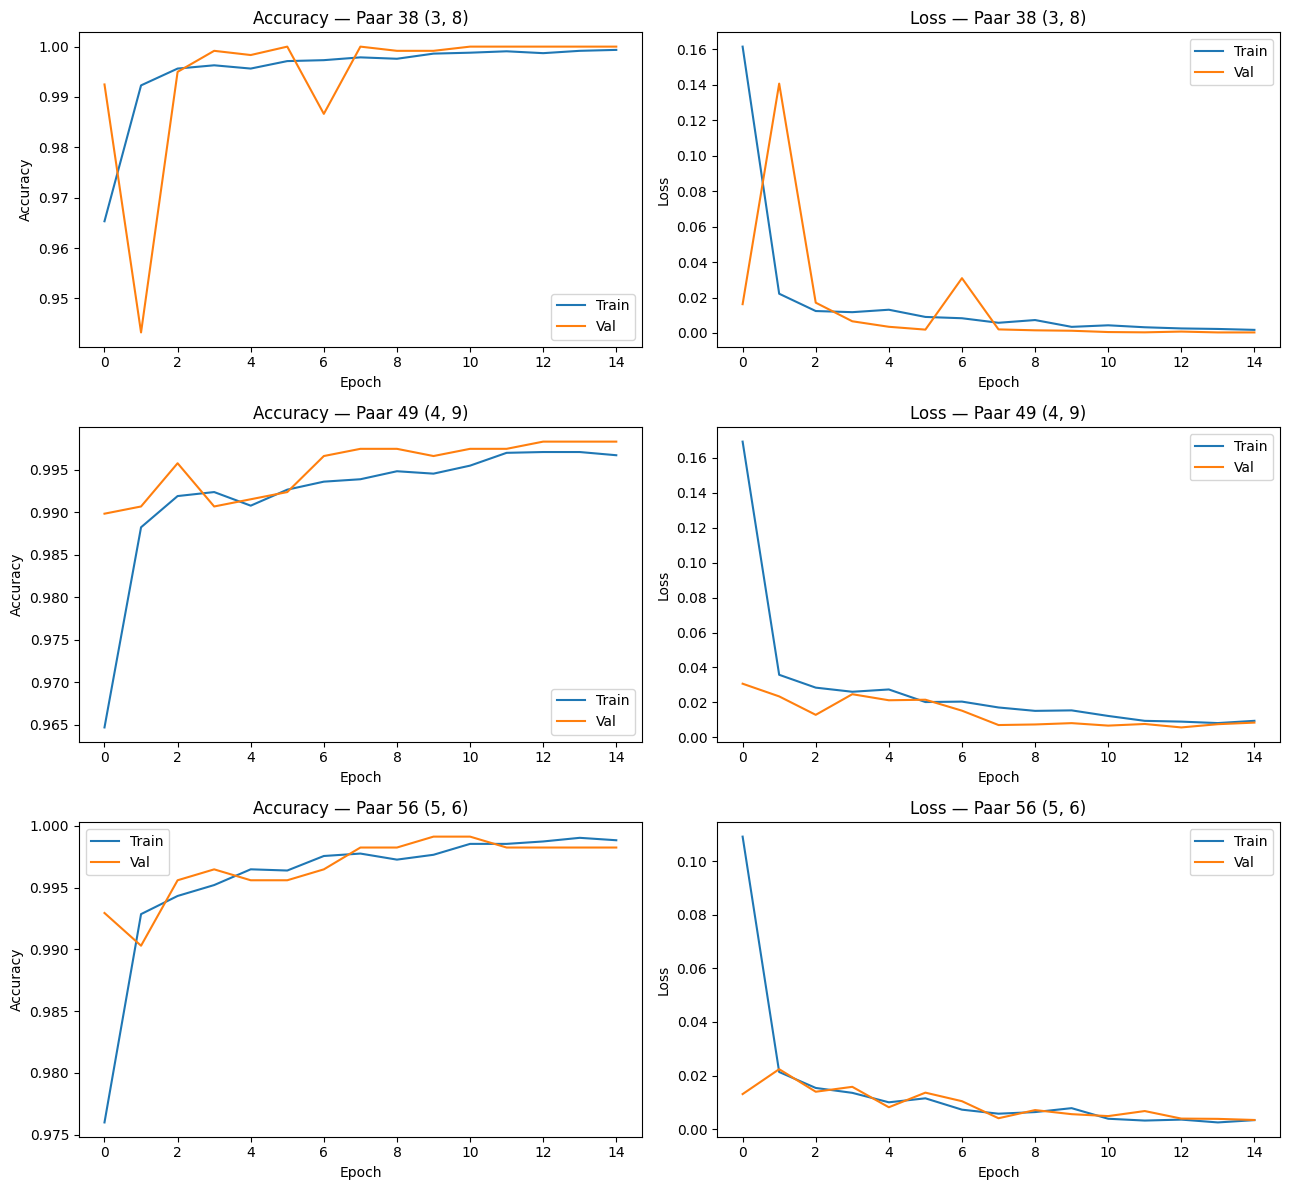

In [11]:
fig, axes = plt.subplots(len(results), 2, figsize=(13, 4 * len(results)))
for row, (pair_key, res) in enumerate(results.items()):
    ax1, ax2 = axes[row]
    ax1.plot(res['train_accs'], label='Train')
    ax1.plot(res['val_accs'], label='Val')
    ax1.set_title(f"Accuracy — Paar {pair_key} {res['digit_pair']}")
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy'); ax1.legend()

    ax2.plot(res['train_losses'], label='Train')
    ax2.plot(res['val_losses'], label='Val')
    ax2.set_title(f"Loss — Paar {pair_key} {res['digit_pair']}")
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'{PLOT_SUFFIX}_all_pairs.png'), dpi=120)
plt.show()


## 7. Testen
Lädt die drei besten Checkpoints und wertet jeweils auf dem offiziellen
MNIST-Testsatz (gefiltert auf das jeweilige Paar) aus.

In [12]:
def load_model(model_path, device):
    """Laedt Checkpoint und baut das Modell wieder auf."""
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    class_names = checkpoint['class_names']
    print(f"Model trained for {checkpoint['epoch']} epochs, val acc: {checkpoint['val_acc']:.2%}")
    print(f"Classes: {class_names}  Digit-Pair: {checkpoint['digit_pair']}")

    model = resnet18_mnist(in_channels=1, n_classes=2).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    return model, class_names, checkpoint['digit_pair']


@torch.no_grad()
def test_on_testset(model, digit_pair, class_names, device, batch_size=BATCH_SIZE):
    """Auswertung auf dem MNIST-Testsatz mit Per-Class-Metriken + Confusion Matrix."""
    test_loader = get_test_loader(digit_pair, batch_size=batch_size)

    model.eval()
    correct = 0
    total = 0
    n_classes = len(class_names)
    class_correct = Counter()
    class_total = Counter()
    confusion = [[0] * n_classes for _ in range(n_classes)]

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)

        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

        for true, pred in zip(labels.cpu().tolist(), preds.cpu().tolist()):
            class_total[true] += 1
            if true == pred:
                class_correct[true] += 1
            confusion[true][pred] += 1

    overall_acc = correct / total
    print(f'\nTest-Ergebnisse — Paar {digit_pair}')
    print('=' * 50)
    print(f'Overall accuracy: {overall_acc:.2%}  ({correct}/{total})')
    print('\nPer-class accuracy:')
    for i, name in enumerate(class_names):
        ct = class_total.get(i, 0)
        cc = class_correct.get(i, 0)
        acc = cc / ct if ct > 0 else 0
        print(f'  {name:>10}: {acc:6.2%}  ({cc}/{ct})')

    fig, ax = plt.subplots(figsize=(4, 3.5))
    im = ax.imshow(confusion, cmap='Blues')
    ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
    ax.set_xticklabels(class_names); ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix — {digit_pair}')
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, str(confusion[i][j]), ha='center', va='center',
                    color='white' if confusion[i][j] > max(map(max, confusion)) / 2 else 'black')
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

    return overall_acc, confusion


Model trained for 6 epochs, val acc: 100.00%
Classes: ['3', '8']  Digit-Pair: (3, 8)

Test-Ergebnisse — Paar (3, 8)
Overall accuracy: 99.80%  (1980/1984)

Per-class accuracy:
           3: 99.70%  (1007/1010)
           8: 99.90%  (973/974)


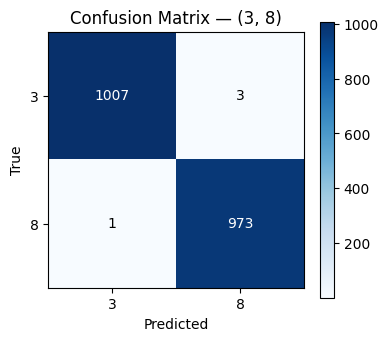

Model trained for 13 epochs, val acc: 99.83%
Classes: ['4', '9']  Digit-Pair: (4, 9)

Test-Ergebnisse — Paar (4, 9)
Overall accuracy: 99.55%  (1982/1991)

Per-class accuracy:
           4: 99.49%  (977/982)
           9: 99.60%  (1005/1009)


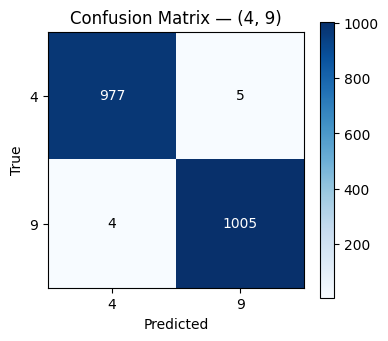

Model trained for 10 epochs, val acc: 99.91%
Classes: ['5', '6']  Digit-Pair: (5, 6)

Test-Ergebnisse — Paar (5, 6)
Overall accuracy: 99.84%  (1847/1850)

Per-class accuracy:
           5: 99.78%  (890/892)
           6: 99.90%  (957/958)


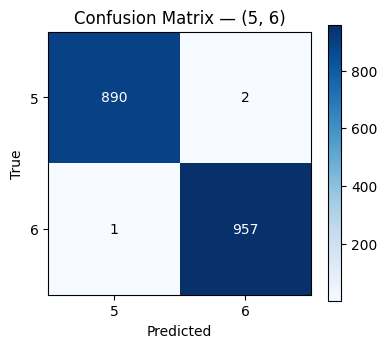

In [13]:
for pair_key in TASK_PAIRS:
    model_path = os.path.join(OUT_DIR, f'best_model_{pair_key}.pth')
    trained_model, class_names, digit_pair = load_model(model_path, device)
    test_on_testset(trained_model, digit_pair, class_names, device)


Model trained for 6 epochs, val acc: 100.00%
Classes: ['3', '8']  Digit-Pair: (3, 8)


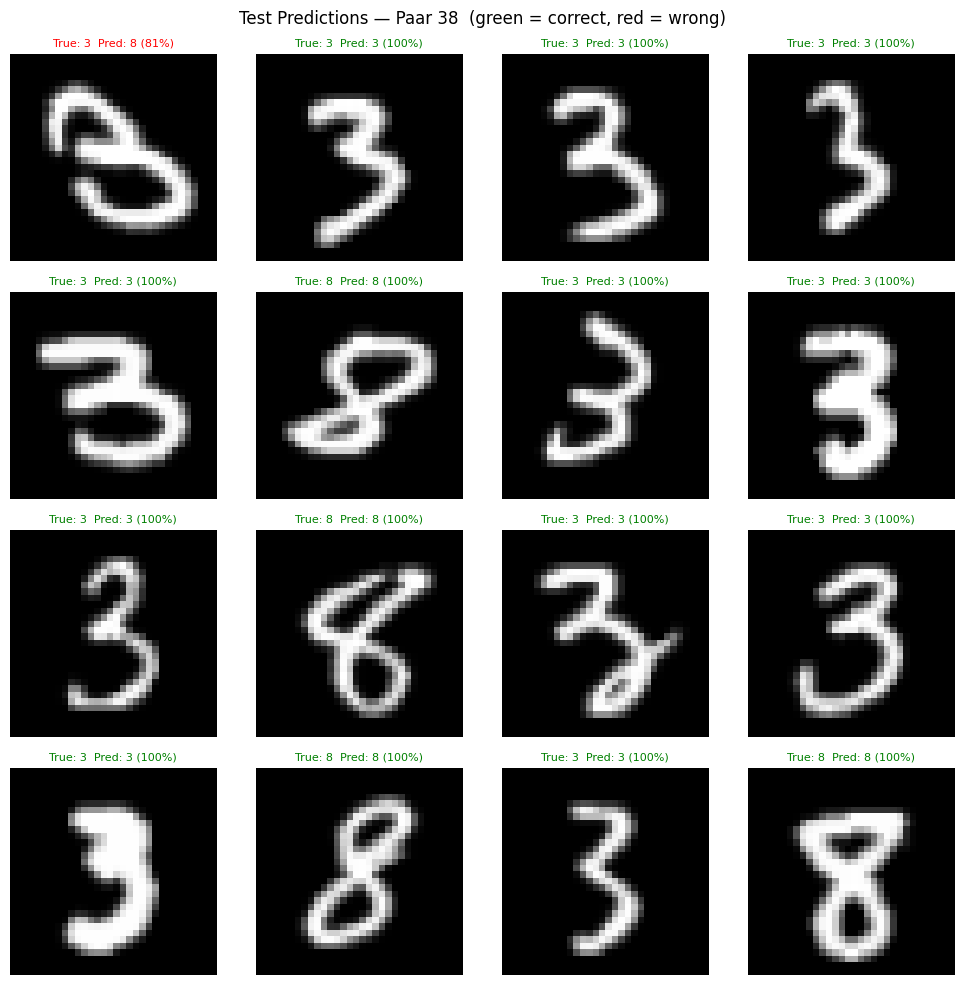

In [14]:
# Sample-Vorhersagen fuer ein Paar (gruen = richtig, rot = falsch)
_pair_key_demo = '38'
model_demo, classes_demo, pair_demo = load_model(
    os.path.join(OUT_DIR, f'best_model_{_pair_key_demo}.pth'), device
)
test_loader_demo = get_test_loader(pair_demo, batch_size=16)
sample_images, sample_labels = next(iter(test_loader_demo))

model_demo.eval()
with torch.no_grad():
    outputs = model_demo(sample_images.to(device))
    sample_probs = torch.softmax(outputs, dim=1).cpu().numpy()
    sample_preds = sample_probs.argmax(axis=1)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for ax, img, true_lbl, pred_lbl, probs in zip(axes.flatten(), sample_images,
                                                sample_labels, sample_preds, sample_probs):
    img_np = denormalise(img).squeeze(0).numpy()
    true_str = classes_demo[int(true_lbl.item())]
    pred_str = classes_demo[int(pred_lbl)]
    confidence = probs[pred_lbl]
    colour = 'green' if pred_lbl == int(true_lbl.item()) else 'red'
    ax.imshow(img_np, cmap='gray')
    ax.set_title(f'True: {true_str}  Pred: {pred_str} ({confidence:.0%})', color=colour, fontsize=8)
    ax.axis('off')
plt.suptitle(f'Test Predictions — Paar {_pair_key_demo}  (green = correct, red = wrong)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'test_predictions_{_pair_key_demo}.png'), dpi=120)
plt.show()
